In [1]:
def set_mpl_params(dpi=150, figsize=(9, 6), grid=True, font_size=16, font_family='serif'):
    """
    Function to set matplotlib parameters for plotting.

    Parameters:
    dpi (int): Dots per inch for the plot. Default is 300.
    figsize (tuple): Figure size for the plot. Default is (18, 12).
    grid (bool): Whether to show grid in the plot. Default is True.
    font_size (int): Font size for the text in the plot. Default is 16.
    font_family (str): Font family for the text in the plot. Default is 'serif'.

    Returns:
    None

    This function updates the default parameters in matplotlib's rcParams dictionary to 
    customize the look and feel of matplotlib plots. The parameters include dots per inch (dpi) 
    for plot resolution, figure size, grid visibility, font size, and font family.
    """
    import matplotlib as mpl
    mpl.rcParams['figure.dpi'] = dpi
    mpl.rcParams['figure.figsize'] = figsize
    mpl.rcParams['axes.grid'] = grid
    mpl.rcParams.update({'font.size': font_size})
    mpl.rcParams['font.family'] = font_family
set_mpl_params()

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("price-and-sales-data.csv")

## Exploratory Analysis

In [3]:
# Display random ten samples
df.sample(10)

,Date,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,year,region
23599,2019-04-07,1.51,30944.22,104.68,2243.05,0.00,28596.49,12978.41,15618.08,0.00,organic,2019,Boston
11683,2017-01-29,1.11,206654.98,87623.67,29999.87,236.88,88794.56,37567.36,50878.59,348.61,conventional,2017,Jacksonville
5447,2015-12-20,1.13,135427.66,40333.06,23867.60,40.52,71186.48,59160.36,12026.12,0.00,conventional,2015,StLouis
2396,2015-06-07,0.98,190396.80,132109.76,13656.80,710.02,43920.22,24338.56,19581.66,0.00,conventional,2015,Jacksonville
6010,2016-01-24,2.28,4508.30,98.73,2428.94,4.06,1976.57,1970.56,6.01,NaN,organic,2016,HartfordSpringfield
11016,2016-12-18,0.94,463483.07,191753.03,80565.05,283.15,190881.84,114872.09,76009.75,0.00,conventional,2016,Atlanta
761,2015-02-22,1.41,109546.92,1709.23,45393.96,131.72,62312.01,61765.34,546.67,0.00,conventional,2015,BuffaloRochester
6222,2016-02-07,1.33,10472.65,1808.94,5778.20,0.00,2885.51,406.67,2478.84,0.00,organic,2016,Detroit
4942,2015-11-15,1.76,13622.89,3015.33,9221.79,43.64,1342.13,353.75,988.38,NaN,organic,2015,NewYork
10270,2016-10-30,1.14,801081.72,432538.75,156225.53,2502.45,209814.99,208940.16,806.01,68.82,conventional,2016,DallasFtWorth


In [4]:
# Display first 10 samples
df.head(10)

,Date,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,year,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.00,conventional,2015,Albany
1,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.00,conventional,2015,Atlanta
2,2015-01-04,NaN,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.00,conventional,2015,BaltimoreWashington
3,2015-01-04,1.01,80034.32,44562.12,24964.23,2752.35,7755.62,6064.30,1691.32,0.00,conventional,2015,Boise
4,2015-01-04,1.02,491738.00,7193.87,396752.18,128.82,87663.13,87406.84,256.29,0.00,conventional,2015,Boston
5,2015-01-04,1.40,116253.44,3267.97,55693.04,109.55,57182.88,57182.88,0.00,0.00,conventional,2015,BuffaloRochester
6,2015-01-04,0.93,5777334.90,2843648.26,2267755.26,137479.64,528451.74,477193.38,47882.56,3375.80,conventional,2015,California
7,2015-01-04,1.19,166006.29,29419.03,47220.75,38568.95,50797.56,NaN,NaN,0.00,conventional,2015,Charlotte
8,2015-01-04,1.11,783068.03,30270.26,550752.19,124506.10,77539.48,72888.46,4651.02,0.00,conventional,2015,Chicago
9,2015-01-04,0.88,228569.58,3274.30,168764.78,1447.06,NaN,17525.31,37445.46,112.67,conventional,2015,CincinnatiDayton


In [5]:
# Display last 10 samples
df.tail(10)

,Date,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,year,region
25151,2019-07-14,1.92,18388.22,211.67,3988.14,17.97,14170.44,11680.25,2490.19,0.00,organic,2019,SouthCarolina
25152,2019-07-14,1.59,135850.62,13396.57,2768.15,4263.07,115422.83,108024.40,7398.43,0.00,organic,2019,SouthCentral
25153,2019-07-14,1.61,121947.41,1868.33,12203.15,20.34,107855.59,86169.59,21686.00,0.00,organic,2019,Southeast
25154,2019-07-14,2.46,5032.63,121.45,1306.08,0.00,3605.10,806.67,2798.43,0.00,organic,2019,Spokane
25155,2019-07-14,2.19,6863.87,56.21,3637.63,5.92,3164.11,3155.89,8.22,0.00,organic,2019,StLouis
25156,2019-07-14,1.66,4007.93,218.47,252.29,0.00,3537.17,1460.65,2076.52,0.00,organic,2019,Syracuse
25157,2019-07-14,1.06,3767.89,129.01,0.00,0.00,3638.88,3635.55,3.33,0.00,organic,2019,Tampa
25158,2019-07-14,1.99,1236969.18,106370.49,209820.63,5606.10,915082.38,667494.94,247562.25,25.19,organic,2019,TotalUS
25159,2019-07-14,2.33,209408.22,23918.57,42432.02,985.67,142071.96,75883.13,66163.64,25.19,organic,2019,West
25160,2019-07-14,1.84,16372.24,1195.71,681.10,2765.31,11730.12,10861.33,868.79,0.00,organic,2019,WestTexNewMexico


In [6]:
# Print the size of the data
print("Dataset has the shape", df.shape)

Dataset has the shape (25161, 13)


In [40]:
# Print the datatype of each column
print(df.dtypes)

Date             object
AveragePrice    float64
TotalVolume     float64
4046            float64
4225            float64
4770            float64
TotalBags       float64
SmallBags       float64
LargeBags       float64
XLargeBags      float64
type             object
year              int64
region           object
dtype: object


In [7]:
# Print the count of missing values
print(df.isnull().sum())

Date              0
AveragePrice    902
TotalVolume     949
4046            900
4225            906
4770            916
TotalBags       890
SmallBags       934
LargeBags       947
XLargeBags      868
type              0
year              0
region            0
dtype: int64


In [8]:
# Display statistical overview
df.describe()

,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,year
count,24259.000000,2.421200e+04,2.426100e+04,2.425500e+04,2.424500e+04,2.427100e+04,2.422700e+04,2.421400e+04,24293.000000,25161.000000
mean,1.396018,9.170913e+05,2.981530e+05,2.958284e+05,2.246362e+04,2.950432e+05,2.124199e+05,7.589924e+04,4405.638467,2016.776877
std,0.384476,3.731937e+06,1.288583e+06,1.209445e+06,1.046621e+05,1.232967e+06,8.693043e+05,3.586079e+05,25806.499886,1.323978
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,1.110000,1.323404e+04,8.225900e+02,3.061135e+03,0.000000e+00,7.319505e+03,4.770445e+03,2.358200e+02,0.000000,2016.000000
50%,1.360000,1.190528e+05,9.855110e+03,2.697755e+04,1.937600e+02,4.625771e+04,3.133734e+04,4.043680e+03,0.000000,2017.000000
75%,1.640000,4.733783e+05,1.141219e+05,1.498719e+05,6.078170e+03,1.394295e+05,1.008827e+05,3.050337e+04,313.890000,2018.000000
max,3.250000,6.371614e+07,2.274362e+07,2.047057e+07,2.546439e+06,2.347299e+07,1.543625e+07,7.864297e+06,844929.830000,2019.000000


In [9]:
# Display correlation matrix
df.corr()

/tmp/ipykernel_3225/1483535905.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,year
AveragePrice,1.000000,-0.189798,-0.207419,-0.169248,-0.177540,-0.173709,-0.174233,-0.162197,-0.110087,0.022026
TotalVolume,-0.189798,1.000000,0.977791,0.968629,0.872152,0.964414,0.973372,0.874147,0.751694,0.029571
4046,-0.207419,0.977791,1.000000,0.925580,0.842456,0.918115,0.931231,0.823114,0.692580,0.007619
4225,-0.169248,0.968629,0.925580,1.000000,0.880154,0.894032,0.914190,0.779562,0.673557,-0.004632
4770,-0.177540,0.872152,0.842456,0.880154,1.000000,0.801221,0.812533,0.699417,0.681737,-0.019138
TotalBags,-0.173709,0.964414,0.918115,0.894032,0.801221,1.000000,0.991109,0.945800,0.816574,0.086012
SmallBags,-0.174233,0.973372,0.931231,0.914190,0.812533,0.991109,1.000000,0.894541,0.802051,0.073336
LargeBags,-0.162197,0.874147,0.823114,0.779562,0.699417,0.945800,0.894541,1.000000,0.756260,0.109252
XLargeBags,-0.110087,0.751694,0.692580,0.673557,0.681737,0.816574,0.802051,0.756260,1.000000,0.098239
year,0.022026,0.029571,0.007619,-0.004632,-0.019138,0.086012,0.073336,0.109252,0.098239,1.000000


## Visualization

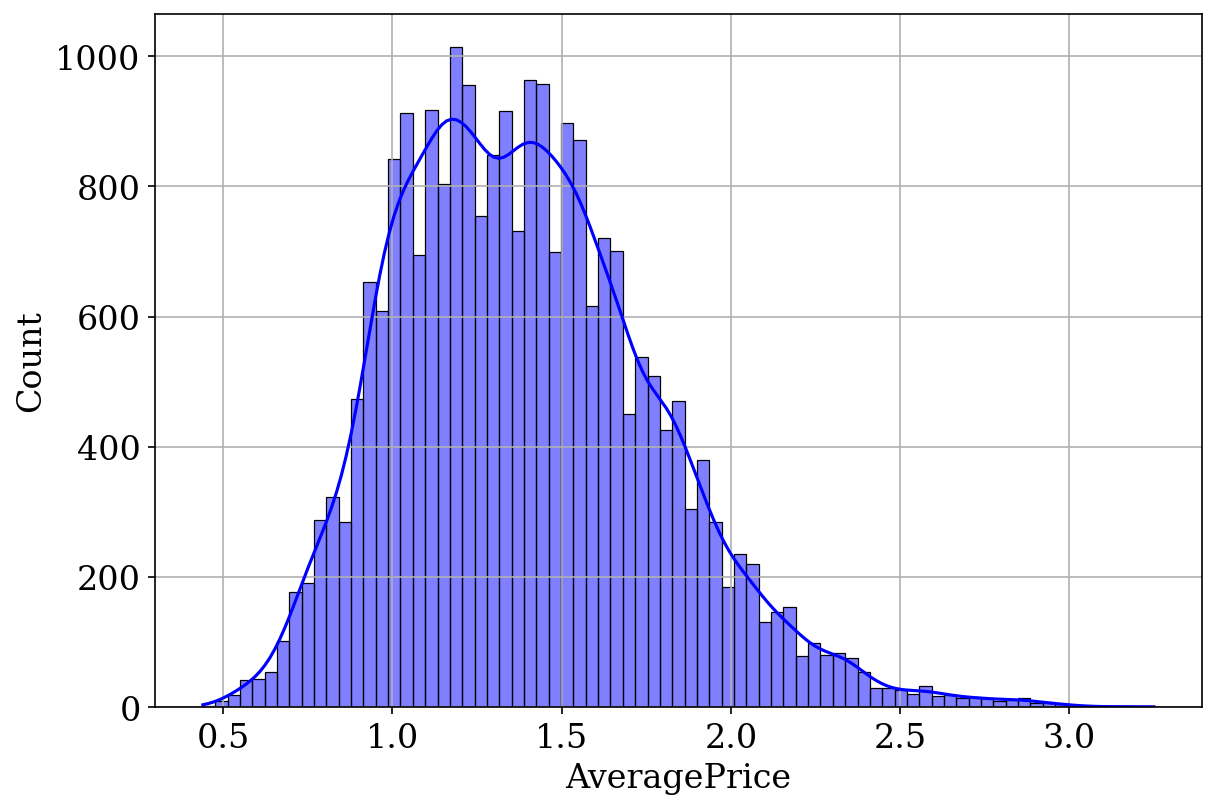

In [10]:
# Univariate visualization
plt.figure()
sns.histplot(df['AveragePrice'], kde=True, color='blue', alpha=0.5)
plt.show()

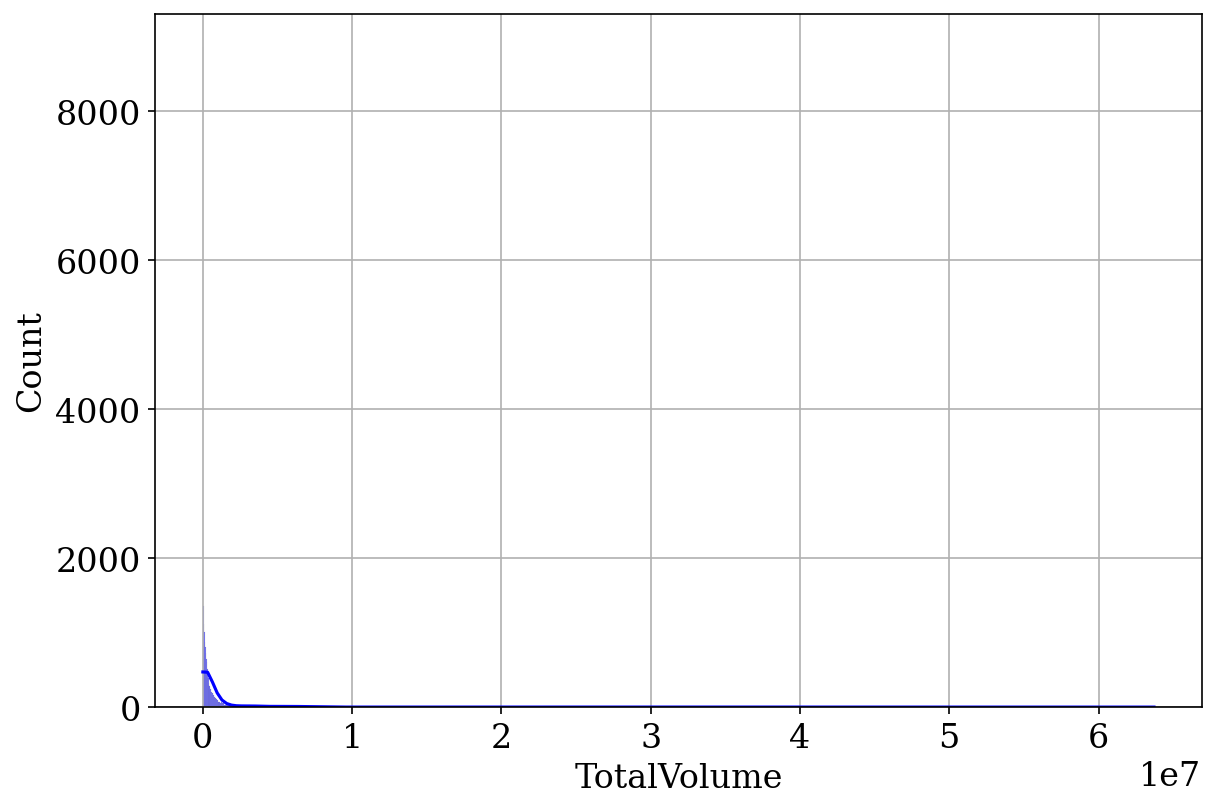

In [11]:
plt.figure()
sns.histplot(df['TotalVolume'], kde=True, color='blue', alpha=0.5)
plt.show()

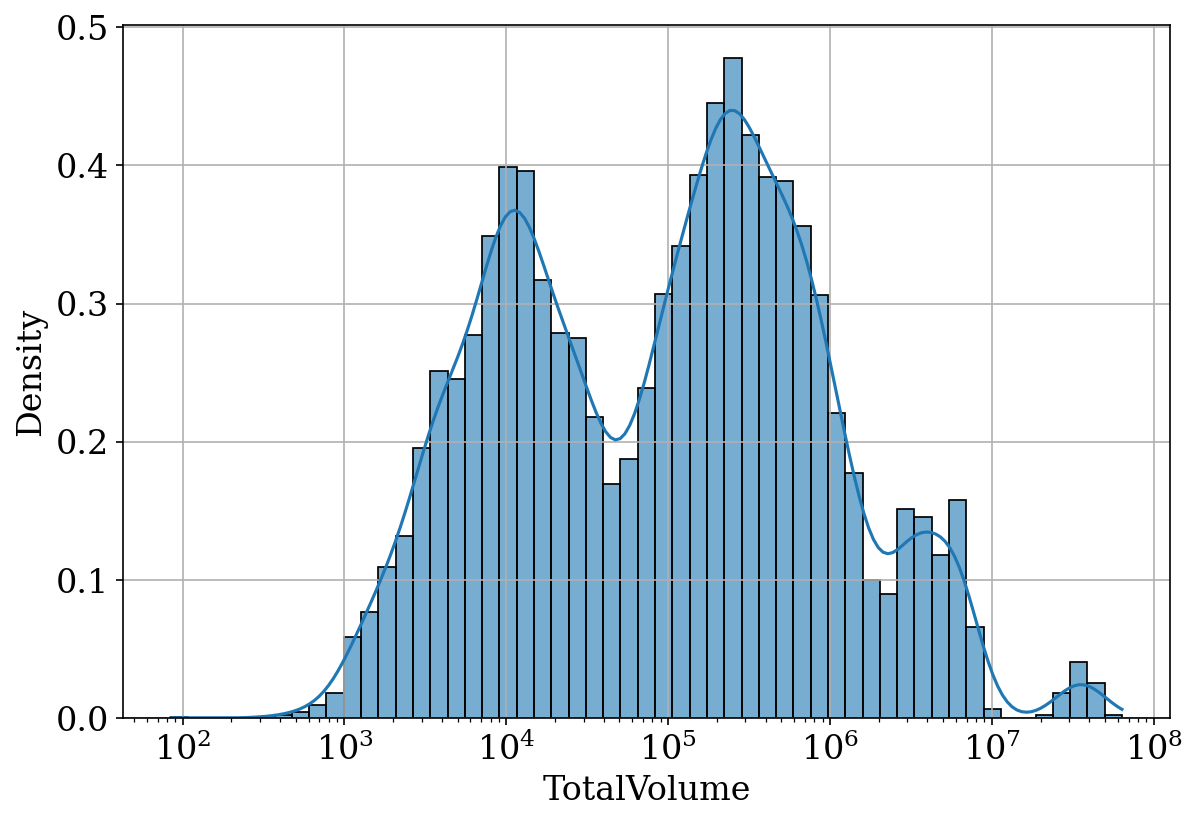

In [12]:
plt.figure()
sns.histplot(data=df['TotalVolume'],
            kde=True,
            stat='density',  # Use density instead of count
            log_scale=True,  # Add log scale for better visualization
            alpha=0.6)  # Increase transparency
plt.show()

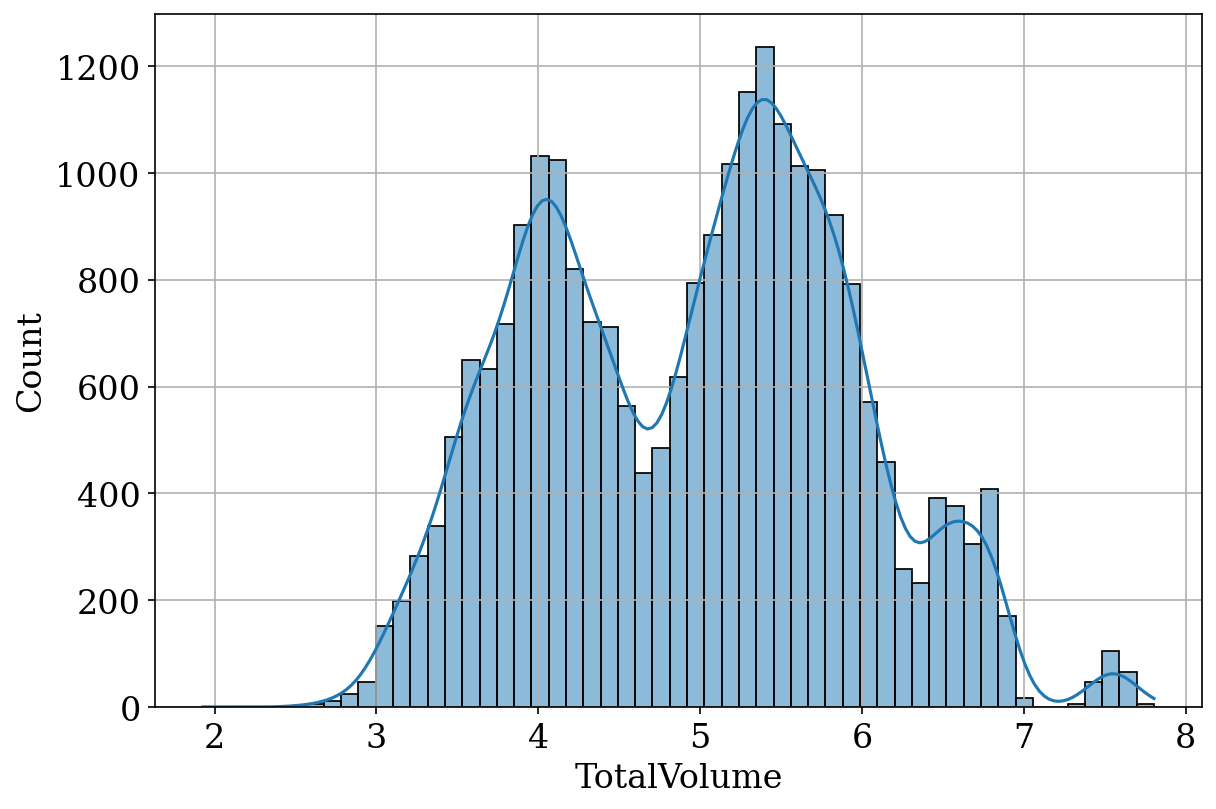

In [13]:
import numpy as np
plt.figure()
sns.histplot(data=np.log10(df['TotalVolume']), kde=True)
plt.show()

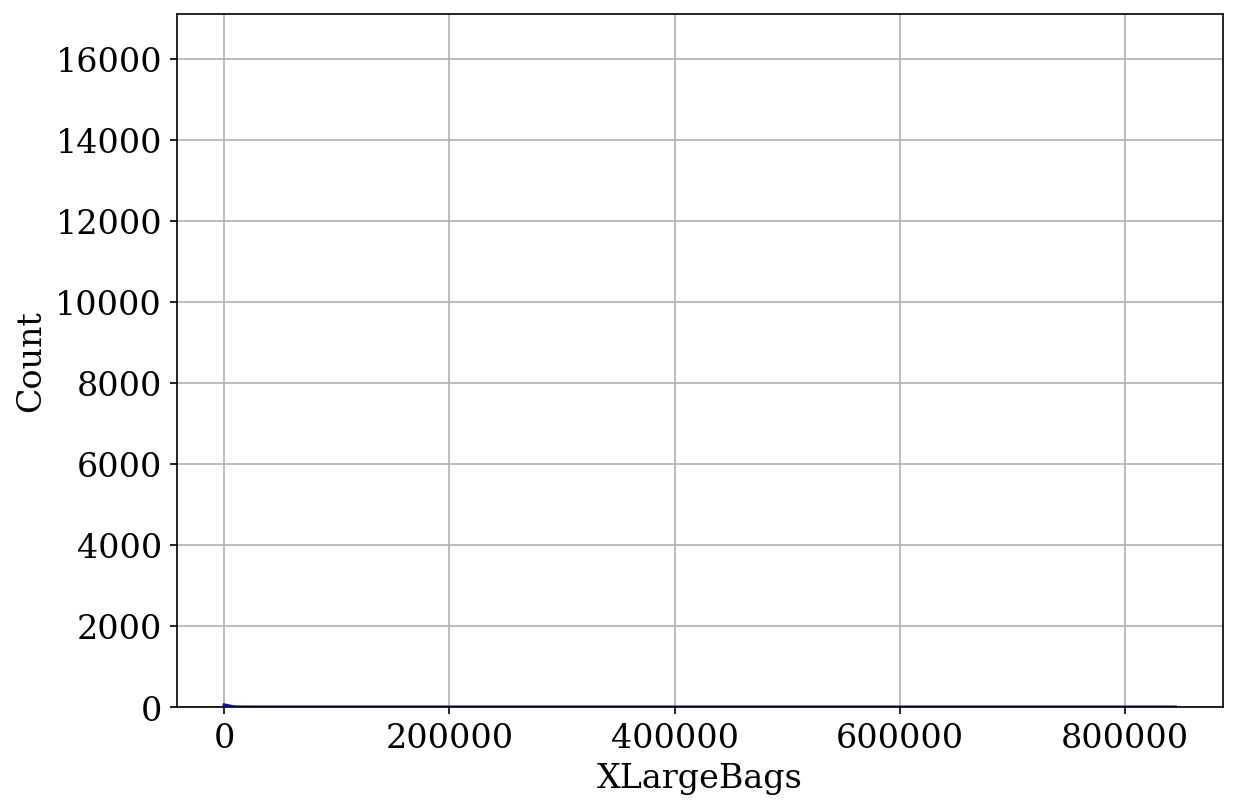

In [14]:
plt.figure()
sns.histplot(df['XLargeBags'], kde=True, color='blue', alpha=0.5)
plt.show()

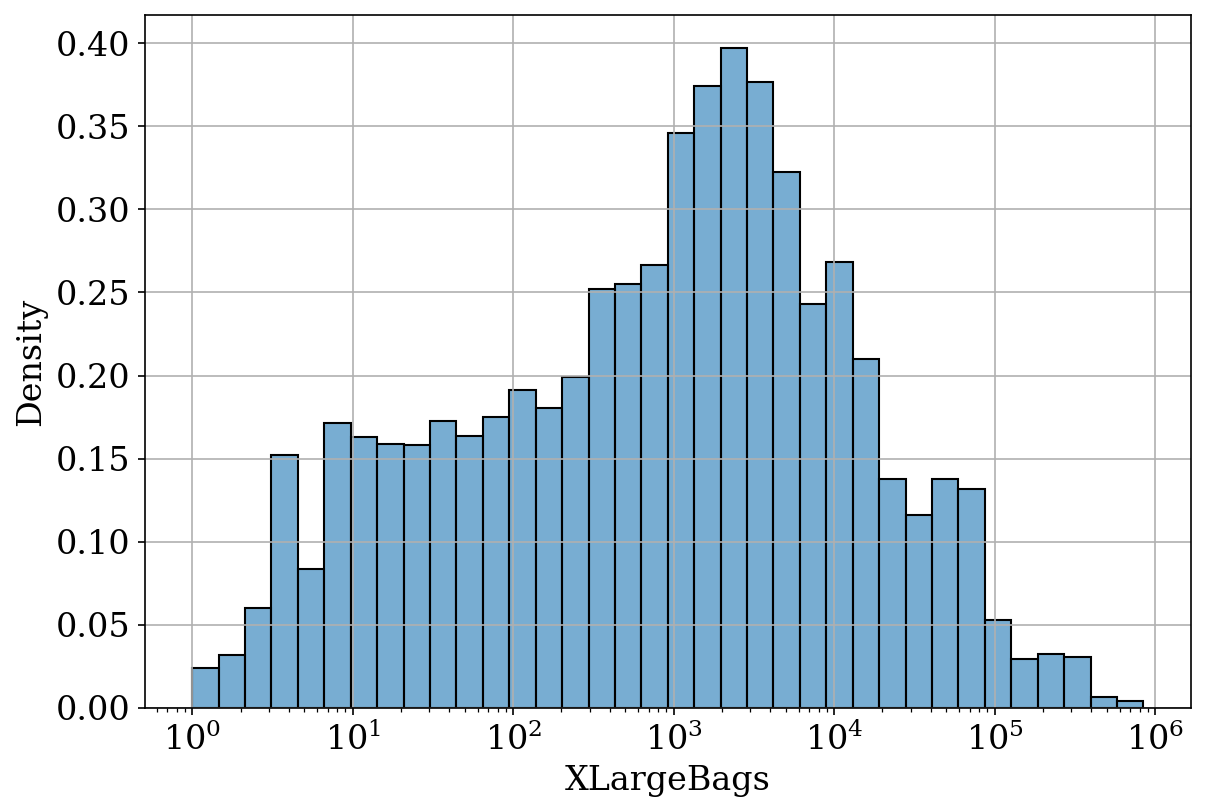

In [15]:
plt.figure()
sns.histplot(data=df['XLargeBags'],
            kde=True,
            stat='density',  # Use density instead of count
            log_scale=True,  # Add log scale for better visualization
            alpha=0.6)  # Increase transparency
plt.show()

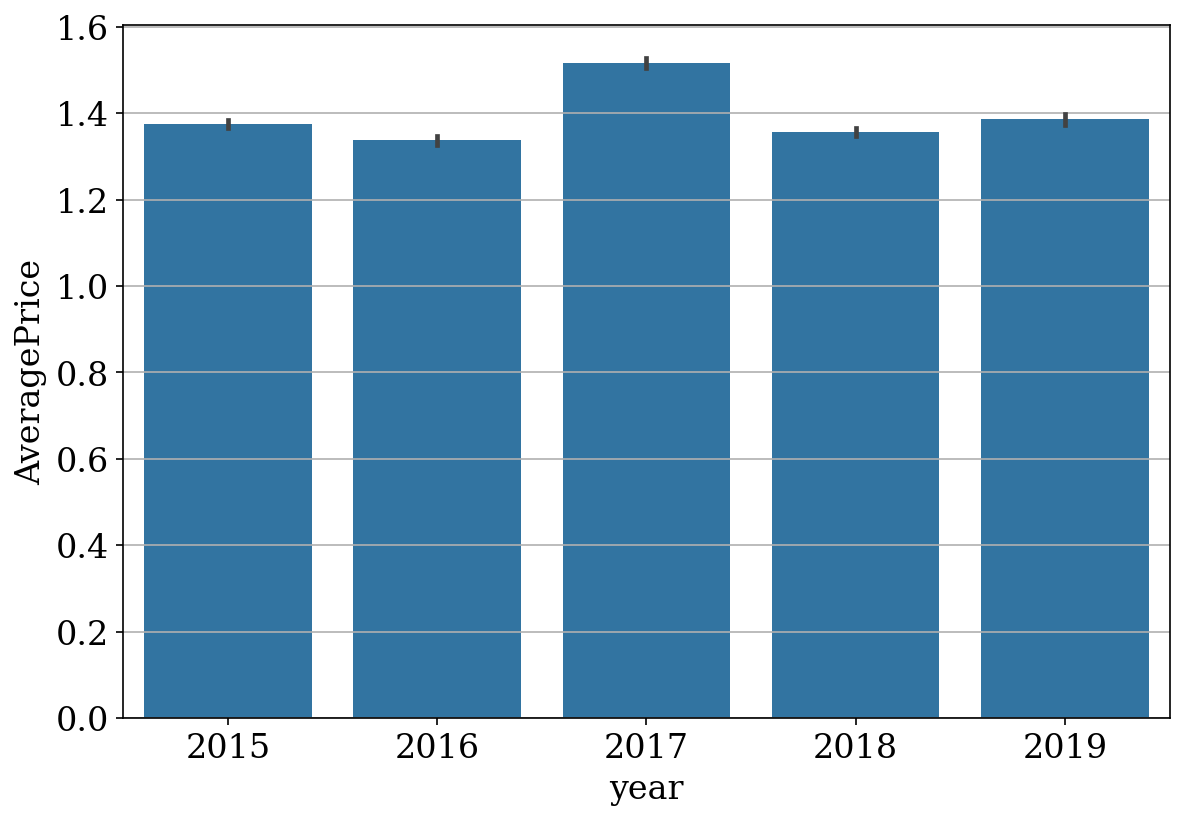

In [16]:
# Bivariate plots
plt.figure()
sns.barplot(x="year", y="AveragePrice", data=df)
plt.show()

/home/manuelsm/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


<Figure size 1350x900 with 0 Axes>

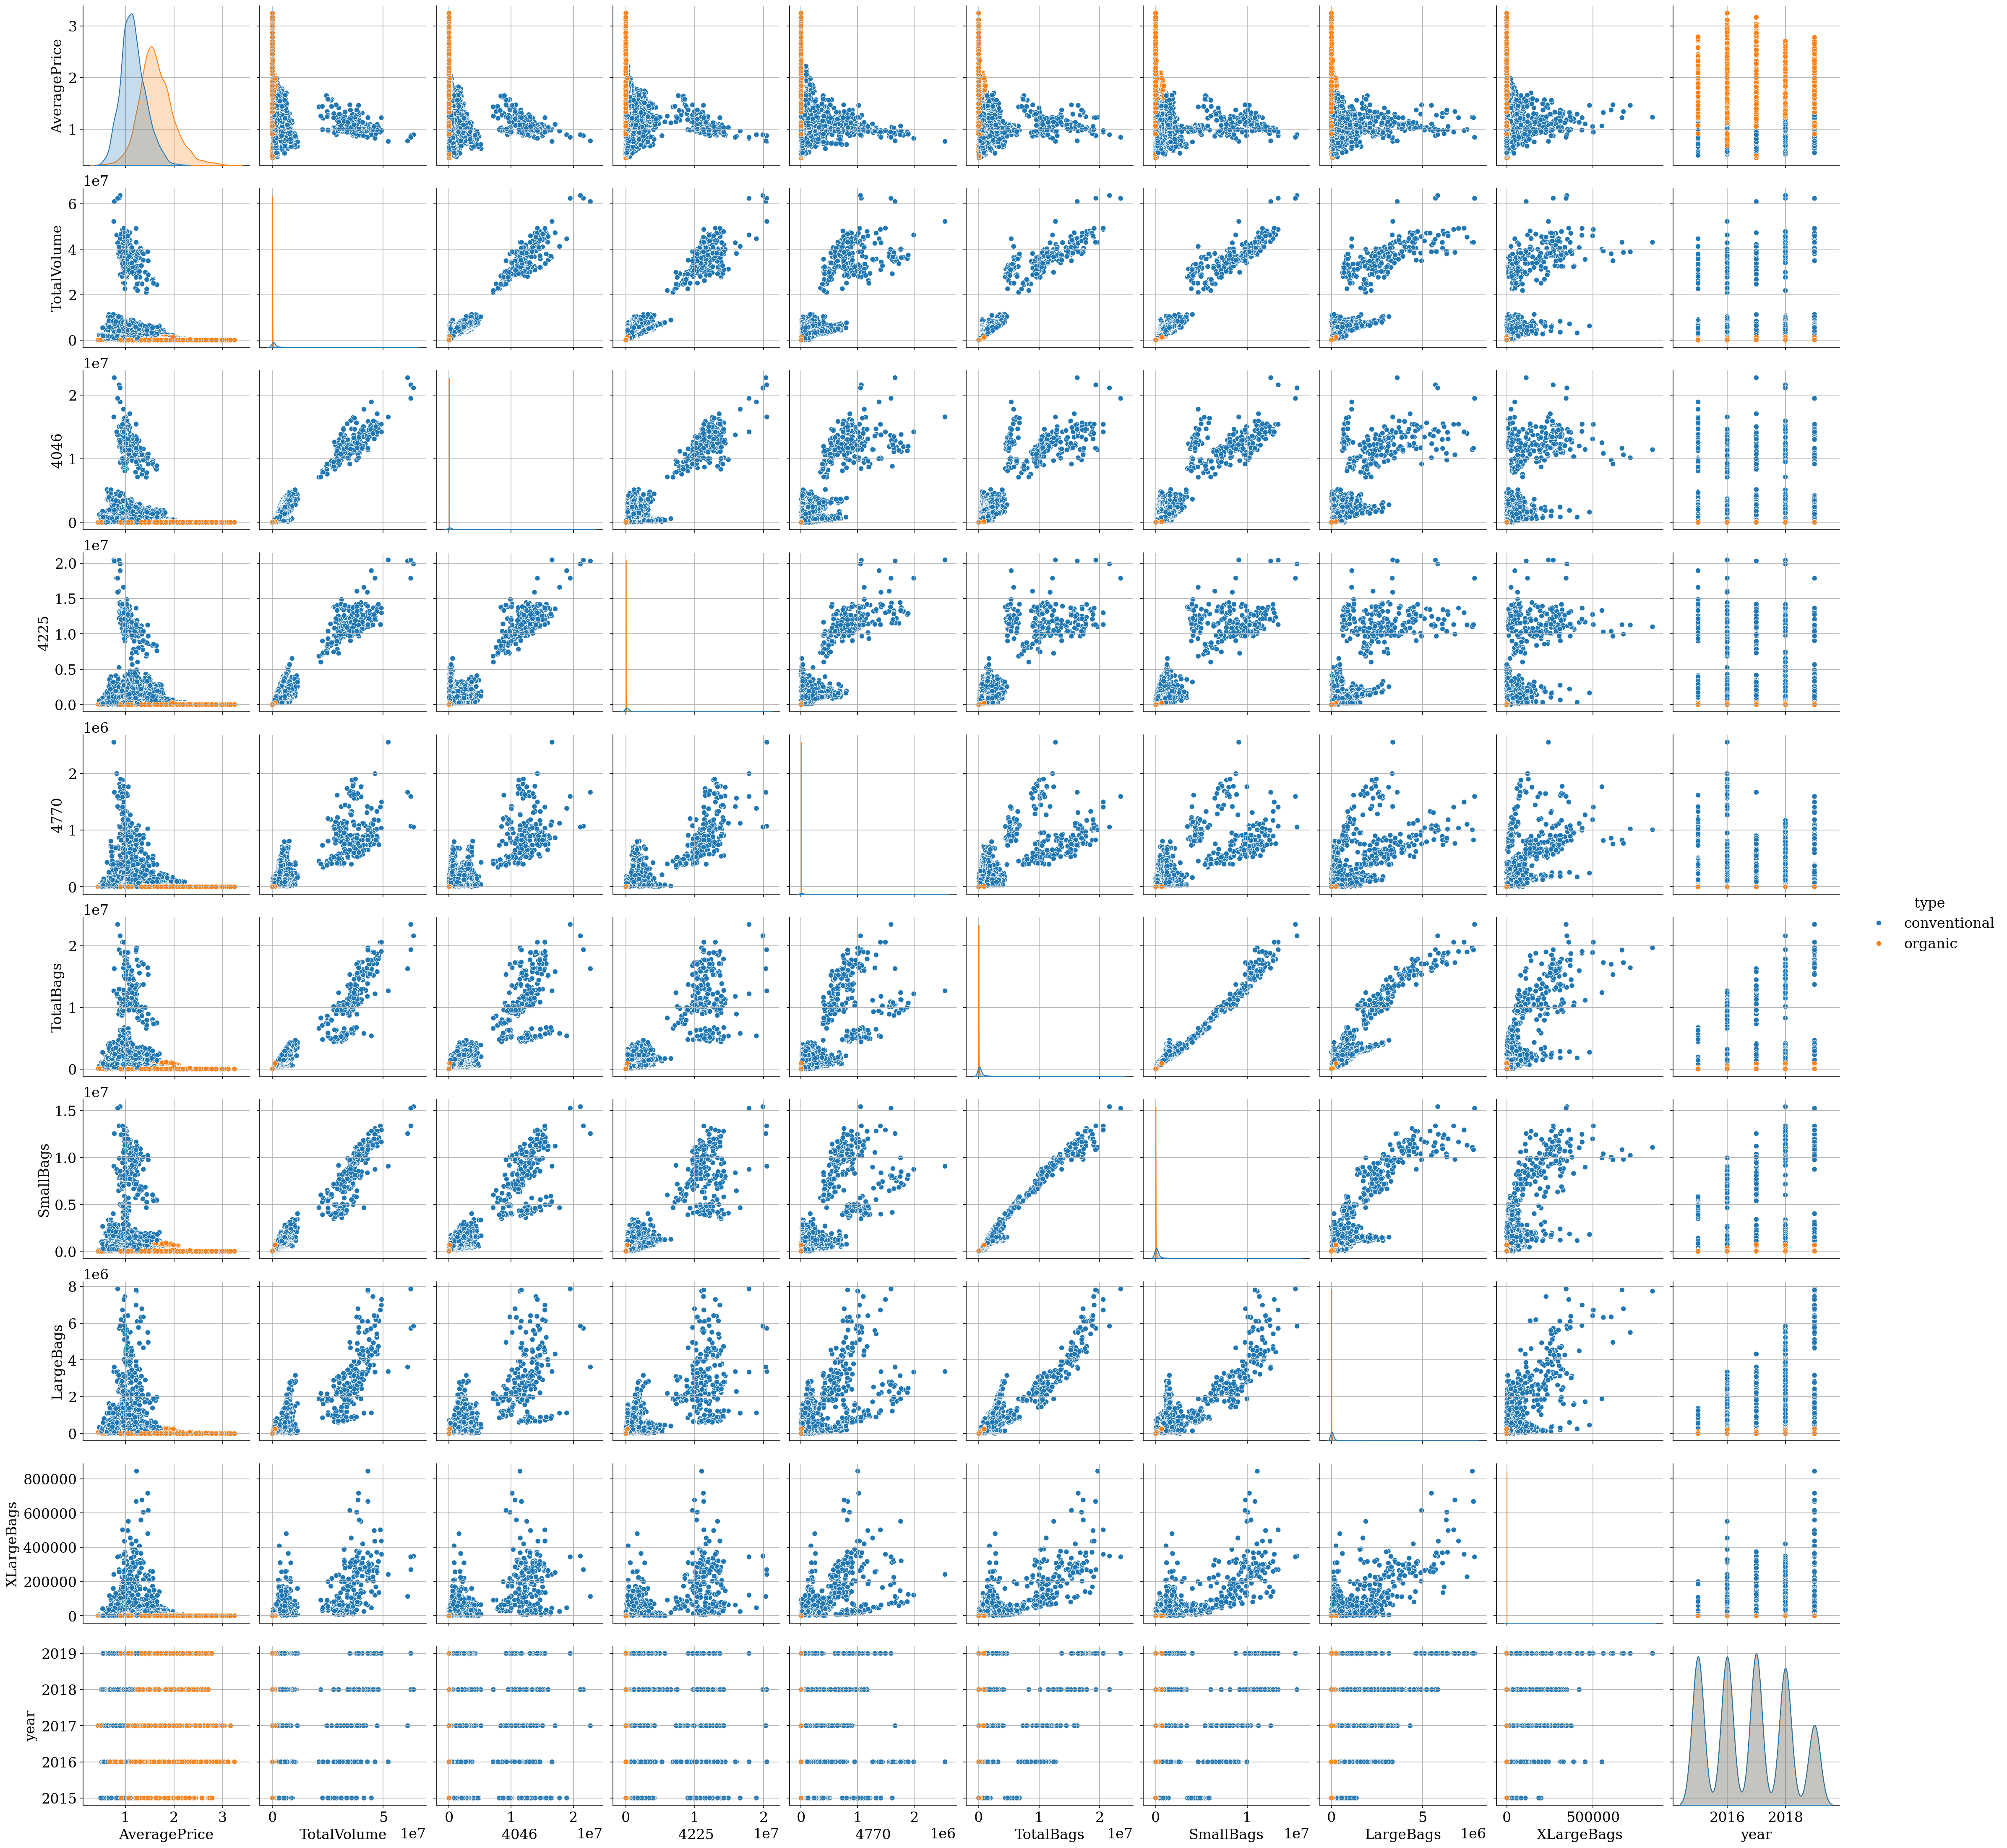

In [17]:
# Bivariate analysis of every feature against every other feature in one graph
plt.figure()
sns.pairplot(df, hue="type", size=3)
plt.show()

<Figure size 1350x900 with 0 Axes>

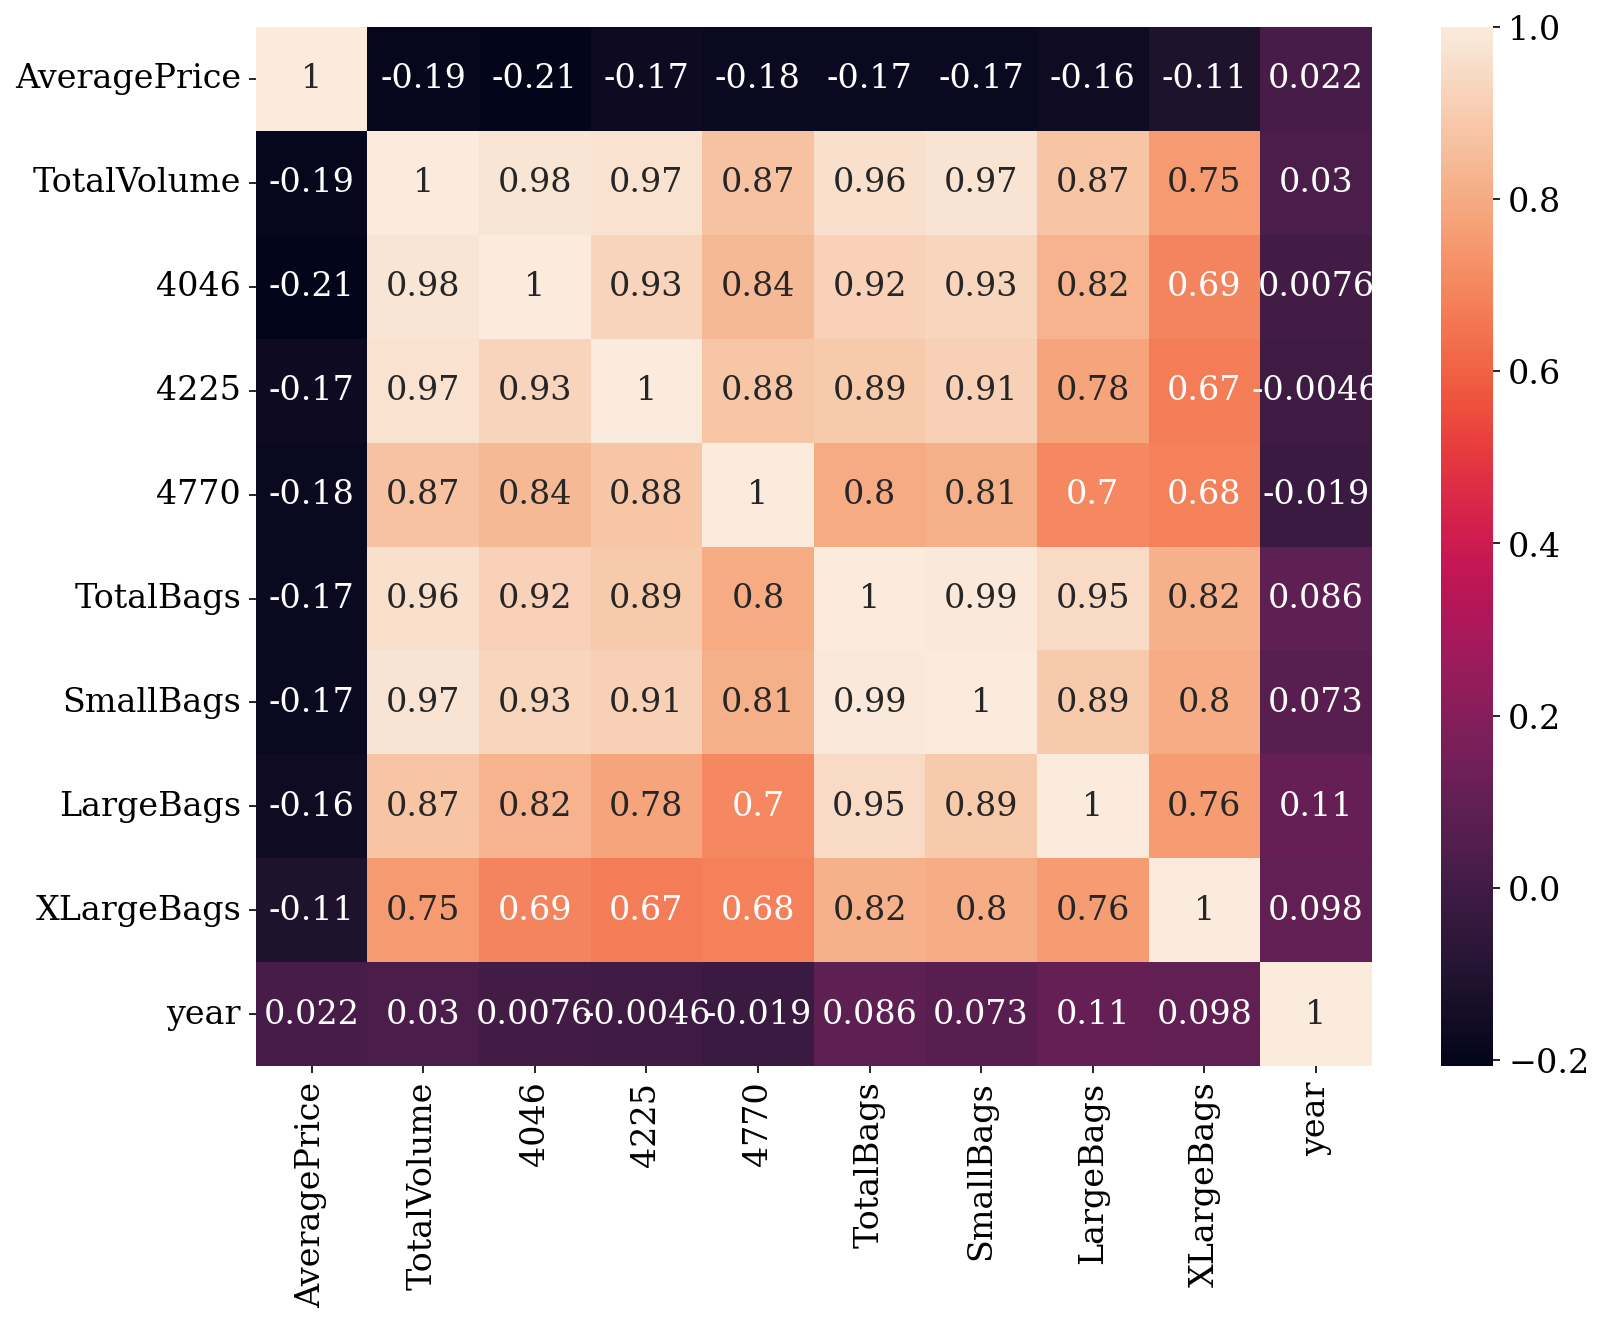

In [18]:
# Correlation matrix heat map
plt.figure()
corrmat = df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, annot=True)
plt.grid()
plt.show()

## Missing values and outliers

In [19]:
#replace missing values with interpolation
data = df.interpolate()
print(data.isnull().sum())
print("Shape of the dataset", data.shape)

Date            0
AveragePrice    0
TotalVolume     0
4046            0
4225            0
4770            0
TotalBags       0
SmallBags       0
LargeBags       0
XLargeBags      0
type            0
year            0
region          0
dtype: int64
Shape of the dataset (25161, 13)


In [20]:
# remove missing values
data = df.dropna(axis=0)
print(data.isnull().sum())
print("Shape of the dataset", data.shape)

Date            0
AveragePrice    0
TotalVolume     0
4046            0
4225            0
4770            0
TotalBags       0
SmallBags       0
LargeBags       0
XLargeBags      0
type            0
year            0
region          0
dtype: int64
Shape of the dataset (18401, 13)


In [22]:
# Find and fill outliers (IQR)

# IQR Method

# Calculate quartiles and IQR
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

clean_data_iqr = df.copy()
outliers_df_iqr = df.copy()

# Align indices before comparison
outliers_iqr = pd.DataFrame(False, index=df.index, columns=df.columns)

# Compare column by column to avoid the warning
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    outliers_iqr[col] = (df[col] < lower_bound[col]) | (df[col] > upper_bound[col])
    column_mean = df[col].mean()
    is_outlier = outliers_iqr[col]
    clean_data_iqr.loc[is_outlier, col] = column_mean
    outliers_df_iqr.loc[~is_outlier, col] = None


In [23]:
clean_data_iqr.head(10)

,Date,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,year,region
0,2015-01-04,1.22,40873.280000,2819.500000,28287.420000,49.90000,9716.460000,9186.93000,529.53,0.000000,conventional,2015.0,Albany
1,2015-01-04,1.00,435021.490000,298153.020752,23821.160000,82.15000,46815.790000,16707.15000,30108.64,0.000000,conventional,2015.0,Atlanta
2,2015-01-04,NaN,788025.060000,53987.310000,295828.429918,22463.61929,141136.680000,137146.07000,3990.61,0.000000,conventional,2015.0,BaltimoreWashington
3,2015-01-04,1.01,80034.320000,44562.120000,24964.230000,2752.35000,7755.620000,6064.30000,1691.32,0.000000,conventional,2015.0,Boise
4,2015-01-04,1.02,491738.000000,7193.870000,295828.429918,128.82000,87663.130000,87406.84000,256.29,0.000000,conventional,2015.0,Boston
5,2015-01-04,1.40,116253.440000,3267.970000,55693.040000,109.55000,57182.880000,57182.88000,0.00,0.000000,conventional,2015.0,BuffaloRochester
6,2015-01-04,0.93,917091.342461,298153.020752,295828.429918,22463.61929,295043.209471,212419.88482,47882.56,4405.638467,conventional,2015.0,California
7,2015-01-04,1.19,166006.290000,29419.030000,47220.750000,22463.61929,50797.560000,NaN,NaN,0.000000,conventional,2015.0,Charlotte
8,2015-01-04,1.11,783068.030000,30270.260000,295828.429918,22463.61929,77539.480000,72888.46000,4651.02,0.000000,conventional,2015.0,Chicago
9,2015-01-04,0.88,228569.580000,3274.300000,168764.780000,1447.06000,NaN,17525.31000,37445.46,112.670000,conventional,2015.0,CincinnatiDayton


In [24]:
outliers_df_iqr.dropna(axis=0, how='all').head(10)

,Date,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,year,region
0,2015-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conventional,NaN,Albany
1,2015-01-04,NaN,NaN,364302.39,NaN,NaN,NaN,NaN,NaN,NaN,conventional,NaN,Atlanta
2,2015-01-04,NaN,NaN,NaN,552906.04,39995.03,NaN,NaN,NaN,NaN,conventional,NaN,BaltimoreWashington
3,2015-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conventional,NaN,Boise
4,2015-01-04,NaN,NaN,NaN,396752.18,NaN,NaN,NaN,NaN,NaN,conventional,NaN,Boston
5,2015-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conventional,NaN,BuffaloRochester
6,2015-01-04,NaN,5777334.9,2843648.26,2267755.26,137479.64,528451.74,477193.38,NaN,3375.8,conventional,NaN,California
7,2015-01-04,NaN,NaN,NaN,NaN,38568.95,NaN,NaN,NaN,NaN,conventional,NaN,Charlotte
8,2015-01-04,NaN,NaN,NaN,550752.19,124506.10,NaN,NaN,NaN,NaN,conventional,NaN,Chicago
9,2015-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conventional,NaN,CincinnatiDayton


In [25]:
# Z-score Method
# Calculate mean and std for each column
means = df.mean(numeric_only=True)
stds = df.std(numeric_only=True)

# Calculate z-scores
z_scores = (df - means) / stds

# Create masks for outliers (typically using threshold of 3)
outliers_zscore = abs(z_scores) > 3

# Get clean data and outliers separately
clean_data_zscore = df.copy()
outliers_df_zscore = df.copy()

# Replace outliers with mean in clean data
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    column_mean = df[column].mean()
    is_outlier = outliers_zscore[column]
    clean_data_zscore.loc[is_outlier, column] = column_mean
    outliers_df_zscore.loc[~is_outlier, column] = None

In [26]:
clean_data_zscore.head(10)

,Date,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,year,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.00,conventional,2015.0,Albany
1,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.00,conventional,2015.0,Atlanta
2,2015-01-04,NaN,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.00,conventional,2015.0,BaltimoreWashington
3,2015-01-04,1.01,80034.32,44562.12,24964.23,2752.35,7755.62,6064.30,1691.32,0.00,conventional,2015.0,Boise
4,2015-01-04,1.02,491738.00,7193.87,396752.18,128.82,87663.13,87406.84,256.29,0.00,conventional,2015.0,Boston
5,2015-01-04,1.40,116253.44,3267.97,55693.04,109.55,57182.88,57182.88,0.00,0.00,conventional,2015.0,BuffaloRochester
6,2015-01-04,0.93,5777334.90,2843648.26,2267755.26,137479.64,528451.74,477193.38,47882.56,3375.80,conventional,2015.0,California
7,2015-01-04,1.19,166006.29,29419.03,47220.75,38568.95,50797.56,NaN,NaN,0.00,conventional,2015.0,Charlotte
8,2015-01-04,1.11,783068.03,30270.26,550752.19,124506.10,77539.48,72888.46,4651.02,0.00,conventional,2015.0,Chicago
9,2015-01-04,0.88,228569.58,3274.30,168764.78,1447.06,NaN,17525.31,37445.46,112.67,conventional,2015.0,CincinnatiDayton


In [27]:
outliers_df_zscore.select_dtypes(include=['float64', 'int64']).dropna(axis=0, how="all").head(10)

,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,year
51,NaN,31324277.73,12357161.34,13624083.05,844093.32,4498940.02,3585321.58,NaN,NaN,NaN
159,NaN,29063542.75,11544810.53,12134773.38,866574.66,4517384.18,3783261.16,NaN,NaN,NaN
267,NaN,29043458.85,11858139.34,11701947.80,831301.90,4652069.81,3873041.26,NaN,NaN,NaN
375,NaN,28470310.84,12167445.03,10734652.82,768020.05,4800192.94,3978636.90,NaN,NaN,NaN
438,NaN,NaN,4794142.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
447,NaN,NaN,NaN,NaN,510153.65,NaN,NaN,NaN,NaN,NaN
457,NaN,NaN,NaN,NaN,388259.15,NaN,NaN,NaN,NaN,NaN
483,NaN,44655461.51,18933038.04,18956479.74,1381516.11,5384427.62,NaN,NaN,NaN,NaN
591,NaN,32137333.01,13308193.40,13381347.54,737939.45,4709852.62,4022474.85,NaN,NaN,NaN
699,NaN,28012520.93,12626615.30,9783489.59,845653.52,4756762.52,4096226.46,NaN,NaN,NaN


## Labelling categorical features

In [28]:
# One Hot Encoding
# Using pandas get_dummies
df_onehot = pd.get_dummies(df, columns=['type'])

In [29]:
df_onehot.sample(10)

,Date,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,year,region,type_conventional,type_organic
6893,2016-03-20,0.87,96171.26,1402.83,26703.78,0.00,68064.65,257.53,67807.12,0.00,2016,Portland,0,1
10772,2016-11-27,1.48,2425.61,104.69,0.00,0.00,2320.92,1277.50,1043.42,0.00,2016,NewOrleansMobile,0,1
15229,2017-09-17,1.58,462796.84,11826.63,323528.38,1322.39,126119.44,89622.85,36416.59,80.00,2017,Boston,1,0
24625,2019-06-16,1.48,730578.79,9171.17,573856.38,2405.34,145145.90,138381.59,6527.65,236.66,2019,Boston,1,0
24641,2019-06-16,1.46,193778.87,77075.08,7889.85,725.95,108087.99,34902.45,71585.54,1600.00,2019,Jacksonville,1,0
8171,2016-06-12,1.05,19398.78,8780.10,51.55,0.00,10567.13,9910.16,656.97,0.00,2016,Houston,0,1
16748,2017-12-24,0.99,1060456.59,565235.94,203334.65,4651.33,287234.67,204606.58,82552.28,75.81,2017,DallasFtWorth,1,0
7831,2016-05-22,1.87,22054.10,623.71,9582.05,278.07,11570.27,11243.91,326.36,0.00,2016,BaltimoreWashington,0,1
4345,2015-10-11,1.13,2329757.67,469059.21,1057488.47,277954.43,525255.56,455592.88,68091.96,1570.72,2015,Midsouth,1,0
22155,2019-01-07,1.40,378882.16,7744.34,294948.08,576.57,75613.17,68977.82,6625.35,10.00,2019,HartfordSpringfield,1,0


In [30]:
# Using scikit-learn
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[['type']])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['type']))
final_df = pd.concat([df, encoded_df], axis=1)

In [31]:
final_df

,Date,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,year,region,type_conventional,type_organic
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.00,conventional,2015,Albany,1.0,0.0
1,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.00,conventional,2015,Atlanta,1.0,0.0
2,2015-01-04,NaN,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.00,conventional,2015,BaltimoreWashington,1.0,0.0
3,2015-01-04,1.01,80034.32,44562.12,24964.23,2752.35,7755.62,6064.30,1691.32,0.00,conventional,2015,Boise,1.0,0.0
4,2015-01-04,1.02,491738.00,7193.87,396752.18,128.82,87663.13,87406.84,256.29,0.00,conventional,2015,Boston,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25156,2019-07-14,1.66,4007.93,218.47,252.29,0.00,3537.17,1460.65,2076.52,0.00,organic,2019,Syracuse,0.0,1.0
25157,2019-07-14,1.06,3767.89,129.01,0.00,0.00,3638.88,3635.55,3.33,0.00,organic,2019,Tampa,0.0,1.0
25158,2019-07-14,1.99,1236969.18,106370.49,209820.63,5606.10,915082.38,667494.94,247562.25,25.19,organic,2019,TotalUS,0.0,1.0
25159,2019-07-14,2.33,209408.22,23918.57,42432.02,985.67,142071.96,75883.13,66163.64,25.19,organic,2019,West,0.0,1.0


In [32]:
# Ordinal Endoding

# Using pandas replace
mapping = {'conventional': 0, 'organic': 1}
ordinal_df = df.copy()
ordinal_df['type_ordinal'] = ordinal_df['type'].replace(mapping)

In [33]:
ordinal_df.sample(10)

,Date,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,year,region,type_ordinal
20152,2018-07-29,1.55,27356.06,5872.45,1762.96,75.59,19645.06,15538.91,4106.15,0.0,organic,2018,Denver,1
8408,2016-06-26,1.19,9043.11,72.94,3824.71,0.00,5145.46,1193.98,3951.48,0.0,organic,2016,Roanoke,1
23720,2019-04-14,1.66,29758.81,5769.18,19384.64,0.00,4604.99,4446.00,158.99,0.0,organic,2019,HartfordSpringfield,1
22101,2018-12-02,1.88,10458.91,83.43,4367.00,1.42,6007.06,6007.06,0.00,0.0,organic,2018,HartfordSpringfield,1
16848,2017-12-31,1.13,79646.97,38196.44,1706.22,6263.00,33481.31,28764.84,4676.67,39.8,conventional,2017,Boise,0
21157,2018-09-30,1.48,139540.48,26000.37,5125.60,0.00,108414.51,85516.70,22897.81,0.0,organic,2018,SouthCentral,1
9202,2016-08-21,1.16,89370.33,1980.35,50039.90,735.71,36614.37,16968.15,19306.22,340.0,conventional,2016,Louisville,0
16121,2017-11-12,1.45,NaN,28196.00,195219.00,203.00,132910.00,108280.00,24629.00,0.0,conventional,2017,Philadelphia,0
24260,2019-05-19,2.33,12455.03,316.16,6010.47,0.00,6128.40,6128.40,0.00,0.0,organic,2019,HartfordSpringfield,1
2448,2015-06-07,1.19,10773.86,9794.34,312.85,0.00,666.67,666.67,0.00,0.0,organic,2015,Houston,1


In [34]:

# Using scikit-learn
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
encoded_df = df.copy()
encoded_df['type_encoded'] = label_encoder.fit_transform(encoded_df['type'])

In [35]:
encoded_df.sample(10)

,Date,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,type,year,region,type_encoded
23359,2019-03-24,0.91,189950.27,53794.32,27347.42,2743.76,106064.77,52913.82,53150.95,0.00,conventional,2019,Pittsburgh,0
14474,2017-07-30,1.32,146069.40,1769.04,65452.36,40.32,NaN,76952.12,592.23,1263.33,conventional,2017,BuffaloRochester,0
13515,2017-05-28,1.56,275488.47,53527.90,137082.84,170.20,84707.53,80202.22,4474.75,30.56,conventional,2017,HarrisburgScranton,0
3678,2015-08-30,1.08,5647385.15,3104607.82,1660274.32,233027.36,NaN,640600.64,5989.25,2885.76,conventional,2015,California,0
11102,2016-12-18,1.83,6977.44,1652.60,2712.82,0.00,2612.02,2609.34,NaN,0.00,organic,2016,PhoenixTucson,1
23302,2019-03-17,1.16,8654.01,104.01,0.00,0.00,8550.00,8550.00,0.00,0.00,organic,2019,Orlando,1
17128,2018-01-14,1.32,20636.96,750.22,3266.56,0.00,16598.98,NaN,1176.19,0.00,organic,2018,Detroit,1
14978,2017-08-27,1.90,3628.25,1.28,973.22,0.00,2653.75,1313.78,1339.97,0.00,organic,2017,Louisville,1
14991,2017-08-27,2.85,15474.64,197.18,2404.96,22.63,12849.87,1238.37,NaN,0.00,organic,2017,Portland,1
5756,2016-01-10,0.59,1276128.92,868817.82,252752.29,12047.67,142511.14,91807.54,50703.60,0.00,conventional,2016,PhoenixTucson,0


In [36]:
#The numeric features are normalized to be between (0,1):

# MinMax Normalization
def normalize(df):
    normalized_df=(df-df.min(numeric_only=True))/(df.max(numeric_only=True)-df.min(numeric_only=True))
    return normalized_df

normalize(df).sample(10)

,4046,4225,4770,AveragePrice,Date,LargeBags,SmallBags,TotalBags,TotalVolume,XLargeBags,region,type,year
11981,0.000064,0.000027,0.000000e+00,0.213523,NaN,0.000921,0.000102,0.000376,0.000169,0.000000,NaN,NaN,0.50
6489,0.002150,0.002023,1.119195e-02,0.209964,NaN,0.001305,0.001453,0.001540,0.002431,0.004112,NaN,NaN,0.25
21440,0.000001,0.000066,0.000000e+00,0.391459,NaN,0.001792,0.000873,0.001174,0.000453,0.000000,NaN,NaN,0.75
15547,0.000741,0.001187,9.888318e-06,0.715302,NaN,0.004633,0.002912,NaN,0.001923,0.000091,NaN,NaN,0.50
13397,0.091327,0.079517,5.409723e-02,0.323843,NaN,0.000501,0.109162,0.074826,0.087873,0.079759,NaN,NaN,0.50
8443,0.006028,NaN,4.456066e-04,0.174377,NaN,0.005318,NaN,0.003630,0.004270,0.007095,NaN,NaN,0.25
17293,0.004452,0.005510,5.089460e-05,0.252669,NaN,0.000057,0.005449,0.003617,0.004692,0.000398,NaN,NaN,0.75
366,0.005596,0.023536,8.362136e-03,0.274021,NaN,0.000101,NaN,0.003543,0.011197,0.000084,NaN,NaN,0.00
1818,0.000373,0.001035,6.440366e-07,0.295374,NaN,0.001331,NaN,0.000446,0.000629,0.000000,NaN,NaN,0.00
24880,0.003122,0.006459,4.748513e-04,0.548043,NaN,0.018065,0.007612,0.011076,0.007288,0.000510,NaN,NaN,1.00


In [38]:
from sklearn.preprocessing import StandardScaler
# Separate continuous columns
continuous_cols = df.select_dtypes(include=['float64', 'int64']).columns
# Exclude datetime or categorical columns that might be in integer format

# Create scaler
scaler = StandardScaler()

# Scale only continuous columns
scaled_continuous = scaler.fit_transform(df[continuous_cols])

# Convert scaled array back to DataFrame with column names
scaled_df = pd.DataFrame(scaled_continuous, columns=continuous_cols, index=df.index)

# Add back any non-scaled columns
for col in df.columns:
    if col not in continuous_cols:
        scaled_df[col] = df[col]


In [39]:
scaled_df.sample(10)

,AveragePrice,TotalVolume,4046,4225,4770,TotalBags,SmallBags,LargeBags,XLargeBags,year,Date,type,region
4103,2.065145,NaN,-0.230690,-0.242196,-0.214634,-0.238314,-0.242992,-0.211584,-0.170722,-1.342101,2015-09-20,organic,WestTexNewMexico
16001,0.218437,-0.210461,NaN,-0.237376,-0.212390,-0.200049,-0.206139,-0.169875,-0.163488,0.168528,2017-11-05,conventional,Jacksonville
5789,-1.628271,-0.228722,-0.227994,-0.235686,-0.214108,-0.200108,-0.243233,NaN,-0.170722,-0.586787,2016-01-10,organic,Denver
5434,-0.691912,0.059694,0.154657,0.037567,0.045768,-0.017142,0.049817,-0.164425,-0.122389,-1.342101,2015-12-20,conventional,Plains
2885,0.244447,-0.245179,-0.231385,-0.243561,-0.214634,-0.238605,-0.244077,-0.209952,-0.170722,-1.342101,2015-07-05,organic,Louisville
20892,-1.004032,-0.066615,0.074560,-0.190483,-0.186809,-0.072303,-0.176921,0.168438,0.254417,0.923843,2018-09-16,conventional,Tampa
9562,0.296467,-0.245291,-0.231339,-0.244515,-0.214634,-0.238058,-0.242602,-0.211647,NaN,-0.586787,2016-09-11,organic,BuffaloRochester
23666,-0.899992,-0.093844,-0.224849,0.160001,-0.204811,-0.184074,-0.177335,-0.184255,-0.170722,1.679158,2019-04-14,conventional,HartfordSpringfield
4244,-0.301762,-0.141722,-0.220426,-0.022415,-0.207426,-0.154454,-0.138946,-0.175471,-0.170722,-1.342101,2015-10-04,conventional,Philadelphia
3181,-0.431812,-0.229683,-0.230704,-0.210255,-0.211434,-0.225356,-0.224583,-0.211654,-0.170722,-1.342101,2015-07-26,conventional,Syracuse
